# Model Calibration

Calibration is the process of ensuring that the predicted probabilities from a model align well with the actual probabilities in the real world

If a classification model outputs a probability of 0.80 for an event occurring, it should mean that on average the event occurs 80% of the time when the model predicts 0.8.  If this is not the case then the model is miscalibrated. 

- For 100 customers, the prediction is 0.7 for churn
- So we expect out of this 100, about 70 customers should actually churn.
- If 80 got churn then it was underestimation
- If 50 got churn then it was over estimation

# Brier Score Loss

Measures mean squared error between predicted probability and the actual label

Overconfident wrong predictions → Higher Brier Score 

$$
\text{Brier Score = Reliability - (Resolution + Uncertainty)}
$$

$$
\text{Calibration Error / Reliability} =  \sum_{b=1}^{B} \frac{n_b}{N} (p_b - \bar{y}_b)^2
$$

$$
\text{Resolution/Discrimination} =  \sum_{b=1}^{B} \frac{n_b}{N} ( \bar{y}_b - \bar{y})^2 
$$

$$
\text{Uncertainty} = \bar{y} ( 1- \bar{y}) 
$$

- Resolution checks if the observed proportion differs from the average proportion.
- Reliability checks if average predicted probability matches the actual proportion in that bin.

- If calibration curve
    - Above diagonal → Under Confident
    - Below diagonal → Over Confident

**Making calibrated probabilities using Platt Scaling**

Given the uncalibrated probabilities from my model and the true target labels, I can train a logistic regression on these probabilities to learn the coefficients A and B, and then use the learned sigmoid function 

$$
P_{\text{calibrated}} = \frac{1}{1+\exp{(Af+B)}}
$$

to transform the uncalibrated probabilities into calibrated probabilities.

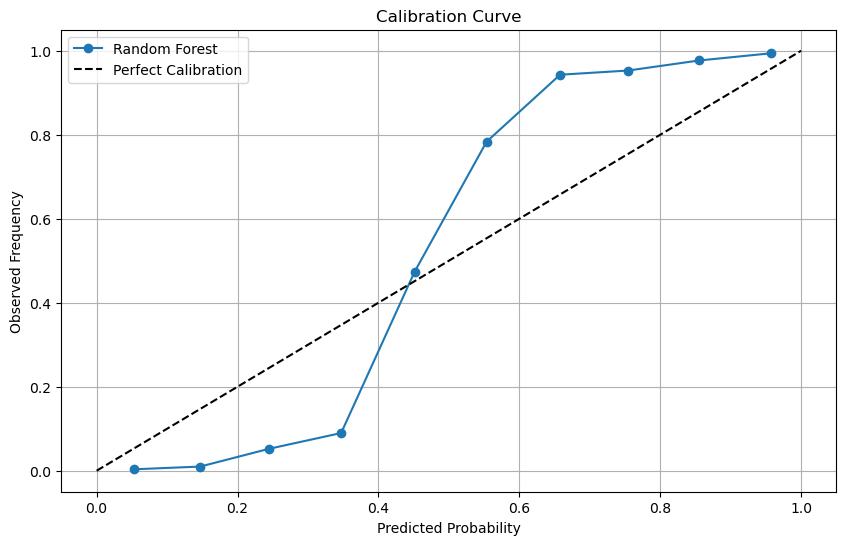

=== Random Forest Metrics ===
Brier Score: 0.0574
Reliability: 0.0202
Resolution : 0.2130
Error      : 0.0572


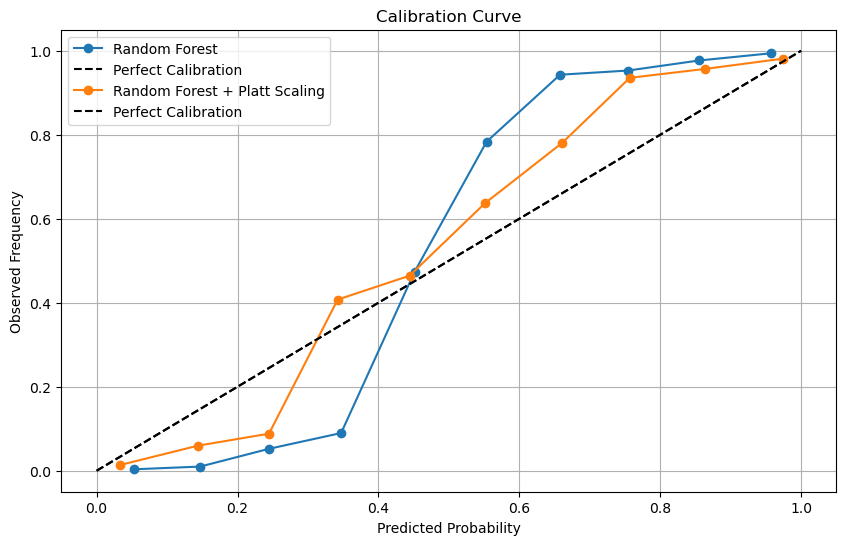


=== Platt Scaled Metrics ===
Brier Score: 0.0389
Reliability: 0.0027
Resolution : 0.2134
Error      : 0.0393


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss

# ---------------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------------

def compute_reliability_resolution_error(y_true, prob_pred, bins=10):
    """Compute reliability, resolution, and error as defined in probabilistic forecasting."""
    bin_ids = np.floor(prob_pred * bins).astype(int)
    bin_ids = np.clip(bin_ids, 0, bins - 1)

    reliability = 0
    resolution = 0
    error = 0
    
    p_avg = np.mean(y_true)

    for b in range(bins):
        mask = bin_ids == b
        if np.sum(mask) == 0:
            continue
        p_bin = np.mean(y_true[mask])
        forecast_bin = np.mean(prob_pred[mask])
        weight = np.sum(mask) / len(y_true)

        reliability += weight * (p_bin - forecast_bin)**2
        resolution += weight * (p_bin - p_avg)**2

    error = reliability - resolution + p_avg * (1 - p_avg)
    
    return reliability, resolution, error


def plot_calibration_diagram(y_true, prob_pred, label):
    """Plot calibration curve for classifier."""
    frac_pos, mean_pred = calibration_curve(y_true, prob_pred, n_bins=10)

    plt.plot(mean_pred, frac_pos, marker='o', label=label)
    plt.plot([0, 1], [0, 1], 'k--', label="Perfect Calibration")
    plt.xlabel("Predicted Probability")
    plt.ylabel("Observed Frequency")
    plt.title("Calibration Curve")
    plt.grid(True)
    plt.legend()

# ---------------------------------------------------------------------------
# Step 1: Generate Data
# ---------------------------------------------------------------------------

X, y = make_classification(
    n_samples=5000, n_features=20, 
    n_informative=10, n_redundant=5, 
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ---------------------------------------------------------------------------
# Step 2: Train Random Forest
# ---------------------------------------------------------------------------

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

rf_probs = rf.predict_proba(X_test)[:, 1]

# ---------------------------------------------------------------------------
# Step 3: Plot calibration + compute metrics
# ---------------------------------------------------------------------------

plt.figure(figsize=(10, 6))
plot_calibration_diagram(y_test, rf_probs, "Random Forest")
plt.show()

brier_rf = brier_score_loss(y_test, rf_probs)
rel_rf, res_rf, err_rf = compute_reliability_resolution_error(y_test, rf_probs)

print("=== Random Forest Metrics ===")
print(f"Brier Score: {brier_rf:.4f}")
print(f"Reliability: {rel_rf:.4f}")
print(f"Resolution : {res_rf:.4f}")
print(f"Error      : {err_rf:.4f}")

# ---------------------------------------------------------------------------
# Step 4: Platt Scaling (Logistic Regression Calibration)
# ---------------------------------------------------------------------------

platt = LogisticRegression(max_iter=500)
platt.fit(rf_probs.reshape(-1, 1), y_test)

platt_probs = platt.predict_proba(rf_probs.reshape(-1, 1))[:, 1]

# ---------------------------------------------------------------------------
# Step 5: Plot calibration after Platt scaling
# ---------------------------------------------------------------------------

plt.figure(figsize=(10, 6))
plot_calibration_diagram(y_test, rf_probs, "Random Forest")
plot_calibration_diagram(y_test, platt_probs, "Random Forest + Platt Scaling")
plt.show()

brier_platt = brier_score_loss(y_test, platt_probs)
rel_platt, res_platt, err_platt = compute_reliability_resolution_error(y_test, platt_probs)

print("\n=== Platt Scaled Metrics ===")
print(f"Brier Score: {brier_platt:.4f}")
print(f"Reliability: {rel_platt:.4f}")
print(f"Resolution : {res_platt:.4f}")
print(f"Error      : {err_platt:.4f}")

